# Forecasting 1h -- variante AUTOREGRESIVA

Copia de `forecasting_1_h_ml.ipynb` con un unico cambio de fondo: se añade
el propio TARGET (`% Iron Concentrate`, `% Silica Concentrate`) como feature
de entrada, ademas de los sensores de proceso.

- **XGBoost** (celda `FEATURE_COLS_LAG_1_AUTOREG`): usa `TARGET.shift(1)`
  -- el ultimo valor de laboratorio conocido en la hora ANTERIOR a la fila
  que se predice.
- **LSTM** (`LSTM_FEATURE_COLS_AUTOREG`): el TARGET entra en la ventana de
  contexto `[t-WINDOW, t)` junto a los sensores -- solo horas anteriores al
  primer paso predicho, nunca el valor que se esta prediciendo.

En ambos casos es un feature autoregresivo legitimo (dato real disponible
en el momento de predecir), no fuga de informacion: el valor que se predice
en la fila/paso `t` nunca aparece como su propio input.


In [1]:
import copy
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [2]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = ['% Iron Concentrate', '% Silica Concentrate']  # columnas a predecir
HORIZON = 1  # horas -- se predice el valor de TARGET dentro de HORIZON horas

df = pd.read_csv(filepath, decimal=',')
df['date'] = pd.to_datetime(df['date'])

# Columnas de laboratorio: se miden una vez por hora y aparecen repetidas en el CSV
# crudo en cada fila de 20s de esa hora (no son 180 medidas independientes).
lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]



In [3]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby('date').cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby('date').cumcount() * 20, unit='s')

# Build a precise timeline from the 'date' column + offset (the row index itself
# is just 0..N-1, it is not a datetime, so we cannot add timedeltas to it directly)
df.index = df['date'] + time_offsets

# --- 2. Filter the Bad Range ---
start_remove = '2017-03-10 01:00:00'
end_remove = '2017-03-29 11:01:00'

# Create mask and apply it
mask = (df.index < start_remove) | (df.index > end_remove)
df = df[mask]

# Drop the empty 19-day gap created by resampling
df = df.dropna()

In [4]:
# Limpieza de outliers por ventana
numeric_df = df.select_dtypes(include=[np.number])

# #### windowed outlier detection using rolling IQR
window_size = 180 # Adjust based on your signal's frequency

# # Calculate rolling quartiles
Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

# Calculate dynamic bounds
lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# En vez de descartar la fila entera cuando una sola columna se sale de rango,
# recortamos (winsorize) cada valor a su limite mas cercano: perdemos el valor
# extremo pero conservamos la fila y el resto de columnas de esa lectura.
n_outliers = ((numeric_df < lower_bound_rolling) | (numeric_df > upper_bound_rolling)).sum().sum()
df[numeric_df.columns] = numeric_df.clip(lower=lower_bound_rolling, upper=upper_bound_rolling, axis=0)

print(f"Row count: {len(df)}")
print(f"Valores recortados (winsorized): {n_outliers}")

Row count: 710639
Valores recortados (winsorized): 299428


In [5]:
# Promedia señales con alta correlación
air_flow_6_7 = [
    'Flotation Column 06 Air Flow', 
    'Flotation Column 07 Air Flow'
]

air_flow_1_2_3 = [
    'Flotation Column 01 Air Flow', 
    'Flotation Column 02 Air Flow', 
    'Flotation Column 03 Air Flow'
]

silica_iron_feed = [
    '% Iron Feed',  
    '% Silica Feed'
]

level_4_5_6_7 = [
    'Flotation Column 04 Level',  
    'Flotation Column 05 Level',
    'Flotation Column 06 Level',  
    'Flotation Column 07 Level'
]

level_1_2_3 = [
    'Flotation Column 01 Level',  
    'Flotation Column 02 Level',
    'Flotation Column 03 Level'
]

# Calculate the row-wise mean for each group and assign to new columns
df['Air Flow 6_7_Mean'] = df[air_flow_6_7].mean(axis=1)
df['Air Flow 1_2_3_Mean'] = df[air_flow_1_2_3].mean(axis=1)
df['Feed Iron_Silica_Mean'] = df[silica_iron_feed].mean(axis=1)
df['Level 4_5_6_7_Mean'] = df[level_4_5_6_7].mean(axis=1)
df['Level 1_2_3_Mean'] = df[level_1_2_3].mean(axis=1)

# Combine the lists and drop the original features
columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
df = df.drop(columns=columns_to_drop)

# '% Iron Feed' y '% Silica Feed' se fusionaron en 'Feed Iron_Silica_Mean';
# actualizamos lab_cols para que siga reflejando las columnas de laboratorio reales.
lab_cols = [c for c in lab_cols if c not in silica_iron_feed] + ['Feed Iron_Silica_Mean']

# sensor_cols apuntaba a los nombres originales (antes de combinar columnas
# correlacionadas); lo recalculamos contra las columnas reales de df para no
# perder las combinadas (Air Flow 6_7_Mean, Air Flow 1_2_3_Mean, Level ..._Mean).
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

# Version sin features (solo media horaria por sensor, sin slope/std) para
# visualizacion externa. Distinta del df de trabajo: no se modifica df aqui.
agg_viz = {c: 'mean' for c in sensor_cols}
agg_viz.update({c: 'first' for c in lab_cols})
df_viz = df.groupby('date', as_index=True).agg(agg_viz).sort_index()
df_viz.to_csv('forecasting_data_historical.csv', index=True)

In [6]:
# Antes de agregar a resolucion horaria: para cada sensor rapido calculamos,
# sobre los ultimos 30 puntos (de 20s) de cada hora, la media, la pendiente de
# regresion lineal (tendencia dentro de la hora) y la desviacion estandar.
# Estas 3 features capturan mas informacion que un simple promedio horario.
def _slope(y):
    y = y.to_numpy()
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n)
    return np.polyfit(x, y, 1)[0]

last30 = df.groupby('date')[sensor_cols].tail(30).groupby(df['date'])
feat_mean = last30.mean().add_suffix('_mean')
feat_slope = last30.apply(lambda g: g.apply(_slope)).add_suffix('_slope')
feat_std = last30.std().add_suffix('_std')

sensor_features = pd.concat([feat_mean, feat_slope, feat_std], axis=1)

# Agregamos a resolucion horaria: 'first' para las columnas de laboratorio
# (todas las filas de la hora ya comparten el mismo valor); los sensores
# rapidos ya se resumieron arriba en sensor_features (media/pendiente/std).
agg = {c: 'first' for c in lab_cols}
df = df.groupby('date', as_index=True).agg(agg).sort_index()
df = df.join(sensor_features)
print(f"File parameters: {df.columns}")
# Rellenamos huecos horarios que falten en el indice (haberlos hay: la campana no
# es perfectamente continua) e interpolamos linealmente.
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
n_missing_hours = len(full_range.difference(df.index))
print(f"Missing hours in original index: {n_missing_hours}")
df = df.reindex(full_range)

for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].ffill()

print(f"Filas (horas): {len(df)} | horas que faltaban en el indice original y se rellenaron: {n_missing_hours}")
print(df[TARGET].describe())

File parameters: Index(['% Iron Concentrate', '% Silica Concentrate', 'Feed Iron_Silica_Mean',
       'Starch Flow_mean', 'Amina Flow_mean', 'Ore Pulp Flow_mean',
       'Ore Pulp pH_mean', 'Ore Pulp Density_mean',
       'Flotation Column 04 Air Flow_mean',
       'Flotation Column 05 Air Flow_mean', 'Air Flow 6_7_Mean_mean',
       'Air Flow 1_2_3_Mean_mean', 'Level 4_5_6_7_Mean_mean',
       'Level 1_2_3_Mean_mean', 'Starch Flow_slope', 'Amina Flow_slope',
       'Ore Pulp Flow_slope', 'Ore Pulp pH_slope', 'Ore Pulp Density_slope',
       'Flotation Column 04 Air Flow_slope',
       'Flotation Column 05 Air Flow_slope', 'Air Flow 6_7_Mean_slope',
       'Air Flow 1_2_3_Mean_slope', 'Level 4_5_6_7_Mean_slope',
       'Level 1_2_3_Mean_slope', 'Starch Flow_std', 'Amina Flow_std',
       'Ore Pulp Flow_std', 'Ore Pulp pH_std', 'Ore Pulp Density_std',
       'Flotation Column 04 Air Flow_std', 'Flotation Column 05 Air Flow_std',
       'Air Flow 6_7_Mean_std', 'Air Flow 1_2_3_Mean_std',

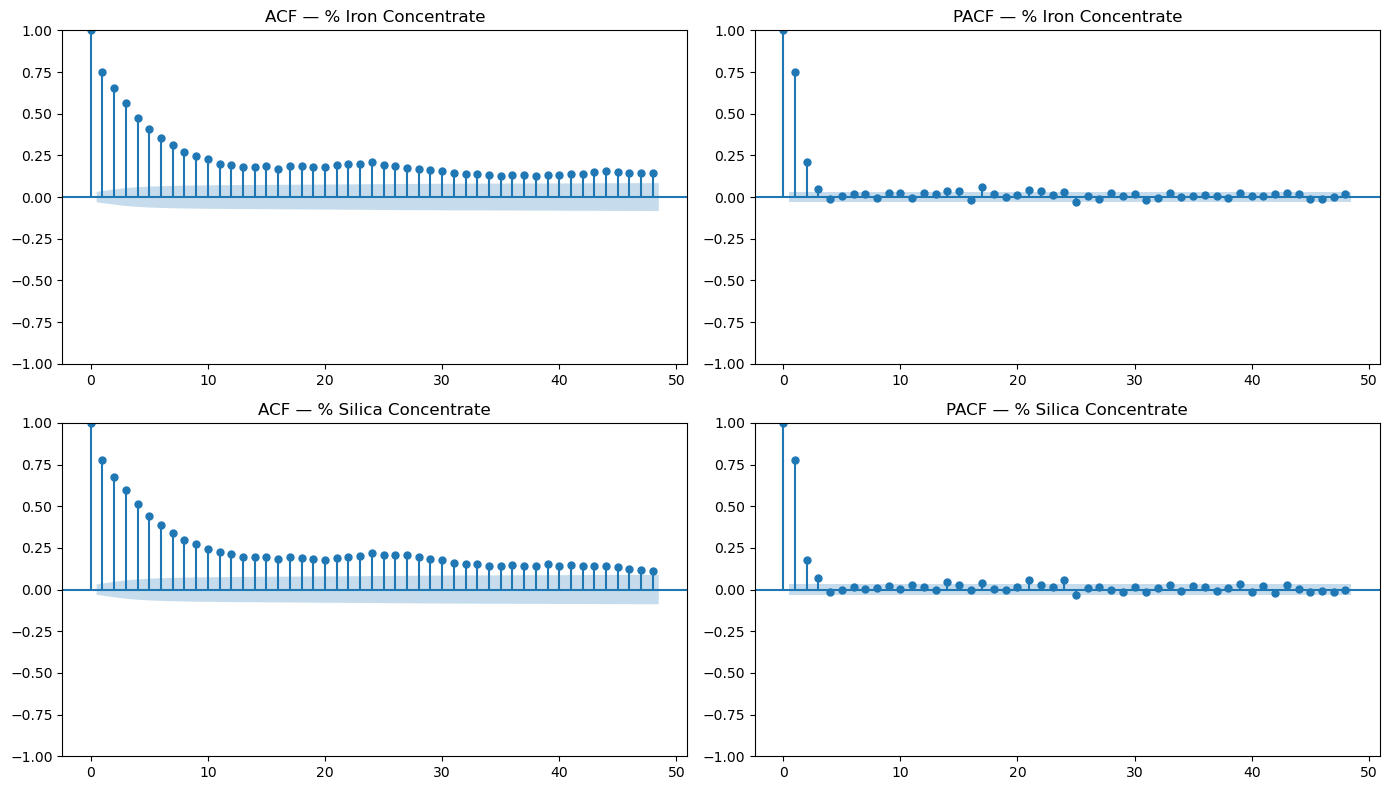

In [7]:
# --- Autocorrelacion (ACF) y autocorrelacion parcial (PACF) de los targets ---
# Se mira esto ANTES de cualquier analisis de correlacion cruzada con los
# sensores: caracteriza cuanta memoria temporal tiene cada target por si
# solo (cuanto explica el pasado del propio target sobre su futuro), lo cual
# es relevante para:
# - Interpretar los umbrales de ruido de MI/xcorr calculados mas abajo: un
#   target con autocorrelacion fuerte hace que el shuffle puro (que rompe
#   toda la memoria) subestime el ruido de fondo (ver celda de umbral por
#   permutacion vs. desplazamiento circular).
# - Decidir si merece la pena anadir lags del propio target como feature
#   (autoregresivo) ademas de los sensores exogenos.
#
# OJO al interpretar: TARGET son medidas de laboratorio de baja frecuencia
# propagadas hacia adelante (ffill) para rellenar la rejilla horaria (ver
# celda anterior). Eso infla artificialmente la autocorrelacion en los
# primeros lags (rachas de valor identico por construccion, no porque el
# proceso tenga esa memoria) -- la ACF/PACF de aqui describe la serie TAL
# COMO ENTRA al modelo (con el ffill ya aplicado), no la dinamica real del
# proceso entre mediciones de laboratorio.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ACF_LAGS = 48  # horas (2 dias) de horizonte para ver memoria de corto/medio plazo

fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, target_col in enumerate(TARGET):
    series = df[target_col].dropna()

    ax_acf = axes[i, 0] if len(TARGET) > 1 else axes[0]
    plot_acf(series, lags=ACF_LAGS, ax=ax_acf, title=f'ACF — {target_col}')

    ax_pacf = axes[i, 1] if len(TARGET) > 1 else axes[1]
    plot_pacf(series, lags=ACF_LAGS, ax=ax_pacf, method='ywm', title=f'PACF — {target_col}')

plt.tight_layout()
plt.show()


In [8]:
# Comprobar la correlacion entre las señales target y las features de laboratorio
# Para cada variable de proceso candidata (elige 3-5 que físicamente deberían
# tener relación causal directa y rápida con sílice/iron, ej. % feed, flujo de aire)
def cross_correlation_lag(sensor, target, max_lag_hours=6):
    sensor_norm = (sensor - sensor.mean()) / sensor.std()
    target_norm = (target - target.mean()) / target.std()
    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag < 0:
            c = np.corrcoef(sensor_norm[:lag], target_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sensor_norm[lag:], target_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(sensor_norm, target_norm)[0, 1]
        correlations.append((lag, c))
    return correlations

for target in TARGET:
    print(f"\nCross-correlation for target: {target}")
    for sensor in df.columns:

        if not "mean" in sensor:
            continue
        correlations = cross_correlation_lag(df[sensor], df[target])

        max_corr = max(correlations, key=lambda x: abs(x[1]))
        print(f"Max correlation in {sensor} at lag {max_corr[0]} hours: {max_corr[1]:.4f}")



Cross-correlation for target: % Iron Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: 0.0963
Max correlation in Amina Flow_mean at lag 2 hours: -0.1902
Max correlation in Ore Pulp Flow_mean at lag -6 hours: 0.1080
Max correlation in Ore Pulp pH_mean at lag -4 hours: 0.2232
Max correlation in Ore Pulp Density_mean at lag 5 hours: 0.0265
Max correlation in Flotation Column 04 Air Flow_mean at lag 6 hours: -0.0491
Max correlation in Flotation Column 05 Air Flow_mean at lag -3 hours: 0.0717
Max correlation in Air Flow 6_7_Mean_mean at lag -4 hours: 0.0220
Max correlation in Air Flow 1_2_3_Mean_mean at lag -3 hours: 0.1285
Max correlation in Level 4_5_6_7_Mean_mean at lag 6 hours: 0.2386
Max correlation in Level 1_2_3_Mean_mean at lag -3 hours: -0.0451

Cross-correlation for target: % Silica Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: -0.1173
Max correlation in Amina Flow_mean at lag 2 hours: 0.2425
Max correlation in Ore Pulp Flow_mean at lag 6 hours: -0

In [9]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression


def _mask_frozen_target(df, target_col, min_run_hours):
    """Devuelve una copia de df[target_col] con NaN en las horas que
    pertenecen a una racha de valor CONSTANTE de min_run_hours horas o mas.

    Importante: pone NaN en el TARGET unicamente -- nunca en los sensores de
    entrada. Un sensor de proceso constante durante horas es una lectura de
    proceso valida (ej. una variable manipulada que no se ha tocado), no un
    artefacto; poner NaN ahi tambien introduciria sesgo. El target aqui es
    una medida de laboratorio de baja frecuencia propagada hacia adelante
    (ffill) para rellenar la rejilla horaria -- sus rachas constantes son
    ese ffill funcionando como se diseño, y hay que excluirlas para no medir
    la relacion sensor-target contra un valor que en realidad no cambio
    porque no se volvio a medir (no porque el proceso estuviera realmente en
    ese valor exacto en cada una de esas horas).

    Se pone NaN (no se elimina la fila) para que la rejilla horaria se
    mantenga completa y continua: asi, al comparar un lag distinto de 0, el
    desplazamiento .shift(lag) opera sobre una rejilla sin huecos y el
    conjunto de instantes de TARGET validos es el mismo para todos los lags
    (cambia unicamente que sensor(t-lag) le corresponde a cada uno). Si en
    vez de esto se eliminaran filas, el numero de pares validos variaria de
    forma no controlada de un lag a otro.
    """
    is_repeated = df[target_col].diff() == 0
    run_id = (~is_repeated).cumsum()
    run_lengths = df.groupby(run_id)[target_col].transform('size')
    frozen = run_lengths >= min_run_hours
    target_masked = df[target_col].where(~frozen)
    return target_masked, frozen


def _check_hourly_grid(df):
    """Verifica que el indice sea una rejilla horaria completa y sin huecos
    (precondicion para que los shifts por pd.Timedelta(hours=lag) comparen
    siempre la hora correcta, sin necesidad de reindexar en cada llamada)."""
    full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
    missing = full_range.difference(df.index)
    if len(missing) > 0:
        raise ValueError(
            f"El indice no es una rejilla horaria continua: faltan {len(missing)} horas "
            f"(ej. {missing[:3].tolist()}). Reindexa/rellena antes de medir correlacion cruzada."
        )
    if not df.index.is_monotonic_increasing:
        raise ValueError("El indice no esta ordenado ascendentemente.")


def cross_correlation_clean(df, sensor_col, target_col, max_lag_hours=6,
                              min_run_hours=12):
    """
    Cross-correlation entre sensor y target por lag horario.

    - El target se pone a NaN (no se elimina la fila) en las horas que
      pertenecen a una racha constante de min_run_hours horas o mas (ver
      _mask_frozen_target). El sensor NUNCA se filtra: sus valores
      constantes son proceso valido.
    - Requiere una rejilla horaria completa (ver _check_hourly_grid) para
      que el shift por Timedelta(hours=lag) siempre alinee la hora correcta.
    - dropna() se aplica DESPUES de alinear sensor y target desplazados, y
      con la MISMA mascara de target (independiente del lag): el conjunto de
      horas de target validas es identico en todos los lags, asi que n_pairs
      es comparable entre lags salvo por los NaN que arrastre el propio
      sensor (que aqui no debería tener, al no filtrarse).
    """
    _check_hourly_grid(df)
    df = df.sort_index()

    target_masked, _ = _mask_frozen_target(df, target_col, min_run_hours)
    sensor = df[sensor_col]

    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        # sensor(t - lag) se compara con target(t): lag>0 => el sensor va
        # 'lag' horas por delante del target (input adelantado, causal);
        # lag<0 => el sensor va por detras.
        sensor_shifted = sensor.shift(lag)
        valid_pairs = pd.concat([sensor_shifted, target_masked], axis=1).dropna()
        n_pairs = len(valid_pairs)
        if n_pairs < 30:
            correlations.append((lag, np.nan, n_pairs))
            continue
        c = np.corrcoef(valid_pairs.iloc[:, 0], valid_pairs.iloc[:, 1])[0, 1]
        correlations.append((lag, c, n_pairs))

    return pd.DataFrame(correlations, columns=['lag_hours', 'correlation', 'n_pairs'])


def mutual_info_by_lag(df, sensor_col, target_col, max_lag_hours=6,
                        min_run_hours=12, random_state=21):
    """Informacion mutua (no lineal, sin signo) entre sensor y target por
    lag. Mismo criterio de mascara de target y misma rejilla horaria que
    cross_correlation_clean, para que ambos metodos se evaluen sobre
    exactamente los mismos pares por lag."""
    _check_hourly_grid(df)
    df = df.sort_index()

    target_masked, _ = _mask_frozen_target(df, target_col, min_run_hours)
    sensor = df[sensor_col]

    mi_rows = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        sensor_shifted = sensor.shift(lag)
        valid_pairs = pd.concat([sensor_shifted, target_masked], axis=1).dropna()
        n_pairs = len(valid_pairs)
        if n_pairs < 30:
            mi_rows.append((lag, np.nan, n_pairs))
            continue
        mi = mutual_info_regression(
            valid_pairs.iloc[:, [0]], valid_pairs.iloc[:, 1], random_state=random_state)[0]
        mi_rows.append((lag, mi, n_pairs))

    return pd.DataFrame(mi_rows, columns=['lag_hours', 'mutual_info', 'n_pairs'])


# Uso: se prueban las 4 candidatas originales en sus 3 variantes (_mean,
# _slope, _std) para ver si la pendiente o la dispersion dentro de la hora
# aportan mas relacion con el target que el simple promedio horario.
base_sensors = ['Amina Flow', 'Level 4_5_6_7_Mean', 'Starch Flow', 'Ore Pulp pH']
sensor_cols = [f'{s}_{suffix}' for s in base_sensors for suffix in ('mean', 'slope', 'std')]
targets = ['% Iron Concentrate', '% Silica Concentrate']  # lista de columnas de target

n_tests = len(sensor_cols) * 13 * len(targets)  # 13 = lags de -6 a 6
bonferroni_threshold_n = 30  # ajusta según tu tamaño de muestra real tras filtrar
# calcula el umbral de significancia real con scipy.stats si quieres ser riguroso

summary_rows = []
for target_name in targets:
    print(f"\n=== {target_name} ===")
    for sensor_col in sensor_cols:
        if sensor_col not in df.columns:
            print(f"\nSensor: {sensor_col} -- no existe en df, se omite")
            continue
        print(f"\nSensor: {sensor_col}")
        res = cross_correlation_clean(df, sensor_col, target_name,
                                        max_lag_hours=6, min_run_hours=12)
        print(res)
        best_xcorr = res.loc[res['correlation'].abs().idxmax()]

        mi_res = mutual_info_by_lag(df, sensor_col, target_name,
                                      max_lag_hours=6, min_run_hours=12)
        print(mi_res)
        best_mi = mi_res.loc[mi_res['mutual_info'].idxmax()]

        summary_rows.append({
            'target': target_name,
            'sensor': sensor_col,
            'variante': sensor_col.rsplit('_', 1)[-1],
            'best_lag_xcorr': best_xcorr['lag_hours'],
            'abs_correlation': abs(best_xcorr['correlation']),
            'correlation': best_xcorr['correlation'],
            'n_pairs_xcorr': best_xcorr['n_pairs'],
            'best_lag_mi': best_mi['lag_hours'],
            'mutual_info': best_mi['mutual_info'],
        })

# --- Resumen: compara mean vs slope vs std para cada sensor base y target,
# con ambos criterios (correlacion lineal + informacion mutua no lineal) uno
# al lado del otro. Ordenado por |xcorr| de mayor a menor; si mutual_info es
# alto pero abs_correlation es bajo para una variante, sugiere una relacion
# no lineal o no monotona que la correlacion cruzada no puede capturar.
summary_df = pd.DataFrame(summary_rows).sort_values(['target', 'abs_correlation'], ascending=[True, False])
print("\n=== Resumen: mejor lag, correlacion e informacion mutua por variante ===")
print(summary_df.to_string(index=False))



=== % Iron Concentrate ===

Sensor: Amina Flow_mean
    lag_hours  correlation  n_pairs
0          -6    -0.162730     3645
1          -5    -0.181759     3646
2          -4    -0.207865     3647
3          -3    -0.228162     3648
4          -2    -0.235323     3649
5          -1    -0.197204     3650
6           0    -0.164781     3651
7           1    -0.137810     3650
8           2    -0.098006     3649
9           3    -0.073132     3648
10          4    -0.062276     3647
11          5    -0.044798     3646
12          6    -0.045647     3645
    lag_hours  mutual_info  n_pairs
0          -6     0.011323     3645
1          -5     0.045701     3646
2          -4     0.060050     3647
3          -3     0.047038     3648
4          -2     0.060862     3649
5          -1     0.000000     3650
6           0     0.028339     3651
7           1     0.034861     3650
8           2     0.028973     3649
9           3     0.018495     3648
10          4     0.008068     3647
11         

              target                              input  best_lag_xcorr  |xcorr|  best_lag_mi       mi
  % Iron Concentrate              Feed Iron_Silica_Mean               5 0.082875            0 0.420069
  % Iron Concentrate             Ore Pulp Density_slope               5 0.040766            0 0.240295
  % Iron Concentrate               Ore Pulp Density_std               6 0.072752            0 0.228988
  % Iron Concentrate                    Starch Flow_std               5 0.057638            0 0.219995
  % Iron Concentrate                     Amina Flow_std               4 0.038922            0 0.210337
  % Iron Concentrate                   Amina Flow_slope               4 0.024017            0 0.199786
  % Iron Concentrate                  Ore Pulp Flow_std               4 0.106656            2 0.196524
  % Iron Concentrate              Level 1_2_3_Mean_mean               3 0.059358            2 0.193010
  % Iron Concentrate                  Starch Flow_slope               3 0

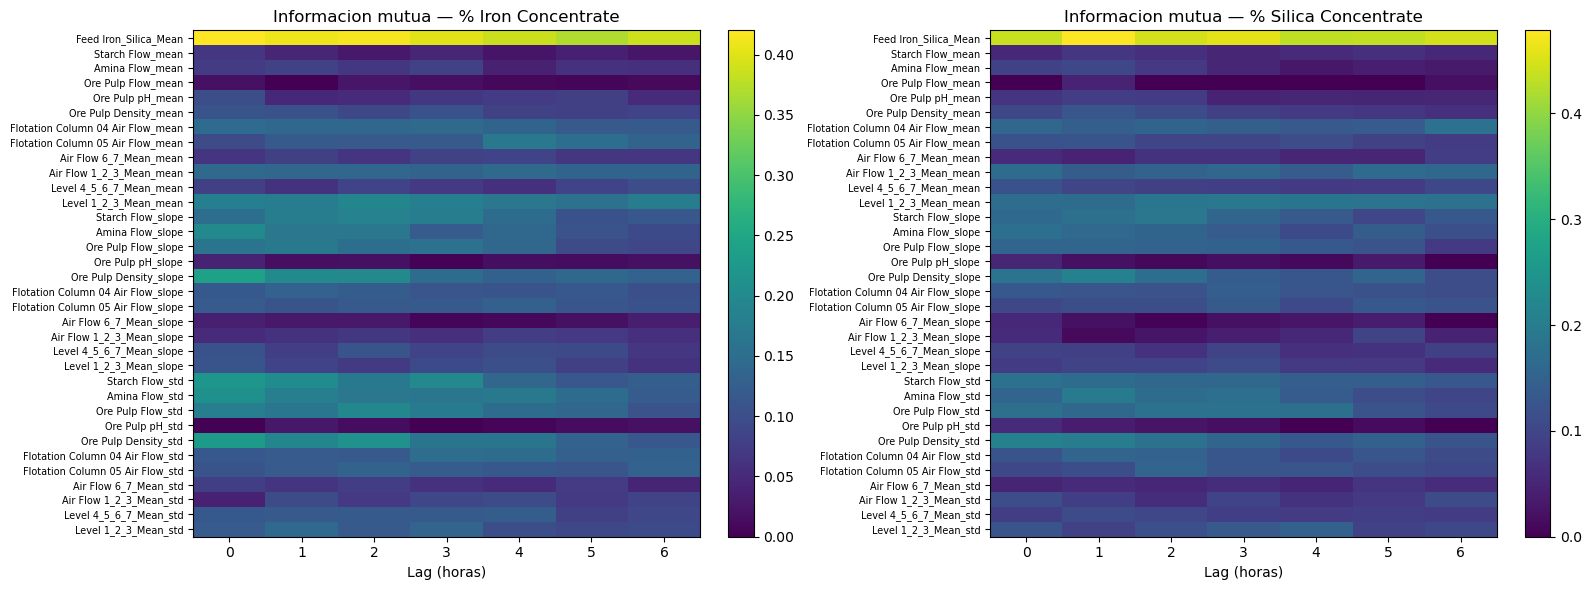

% Iron Concentrate: L (decorrelacion < 0.2) = 12 horas
% Silica Concentrate: L (decorrelacion < 0.2) = 29 horas

--- % Iron Concentrate ---


KeyboardInterrupt: 

In [10]:
# --- Correlacion cruzada + informacion mutua vs. lag, por señal de entrada ---
# Objetivo: para cada parametro de entrada -- sensores + columnas de
# laboratorio, en sus 3 variantes por hora (_mean, _slope, _std) -- ver a
# que lag esta mas relacionado con cada target y con que fuerza, para decidir
# que variante y lag merece la pena meter como input al modelo.
#
# - Correlacion cruzada (lineal, con signo): corr(input(t-lag), target(t))
# - Informacion mutua (no lineal, sin signo): capta cualquier dependencia,
#   incluida no monotona, pero no dice si la relacion es directa o inversa.
#
# Se usa df (agregacion horaria CON _mean/_slope/_std) y SOLO el tramo de
# train para no filtrar informacion del test en la seleccion de lags.
from sklearn.feature_selection import mutual_info_regression

# input_cols viene de 'df' (agregacion horaria CON features derivadas:
# _mean/_slope/_std por sensor), no de df_viz (que solo tiene la media simple)
# -- asi entran al analisis tambien la pendiente y la dispersion dentro de
# cada hora, no solo el promedio, y compiten las 3 variantes entre si por
# senal y lag.
MAX_LAG = 6  # horas
input_cols = [c for c in df.columns if c not in TARGET]

train_cutoff = df.index[int(len(df) * 0.70)]
mi_train = df.loc[:train_cutoff]

xcorr_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}
mi_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}

for target_col in TARGET:
    y = mi_train[target_col]
    for lag in range(MAX_LAG + 1):
        shifted = mi_train[input_cols].shift(lag)
        valid = shifted.join(y, how='inner').dropna()
        if len(valid) < 30:
            continue
        X_lag = valid[input_cols]
        y_lag = valid[target_col]

        xcorr_results[target_col][lag] = X_lag.corrwith(y_lag)

        mi = mutual_info_regression(X_lag, y_lag, random_state=21)
        mi_results[target_col][lag] = mi

# --- Mejor lag por señal segun cada criterio ---
summary_rows = []
for target_col in TARGET:
    best_xcorr_lag = xcorr_results[target_col].abs().idxmax(axis=1)
    best_xcorr_val = xcorr_results[target_col].abs().max(axis=1)
    best_mi_lag = mi_results[target_col].idxmax(axis=1)
    best_mi_val = mi_results[target_col].max(axis=1)
    for col in input_cols:
        summary_rows.append({
            'target': target_col,
            'input': col,
            'best_lag_xcorr': best_xcorr_lag[col],
            '|xcorr|': best_xcorr_val[col],
            'best_lag_mi': best_mi_lag[col],
            'mi': best_mi_val[col],
        })

summary = pd.DataFrame(summary_rows).sort_values(['target', 'mi'], ascending=[True, False])
print(summary.to_string(index=False))

# --- Heatmaps: fuerza de relacion (MI) por señal x lag, un heatmap por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(8 * len(TARGET), 6))
for ax, target_col in zip(axes, TARGET):
    im = ax.imshow(mi_results[target_col].values, aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(input_cols)))
    ax.set_yticklabels(input_cols, fontsize=7)
    ax.set_xticks(range(MAX_LAG + 1))
    ax.set_xlabel('Lag (horas)')
    ax.set_title(f'Informacion mutua — {target_col}')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# --- Umbral de ruido por permutacion: MI que se obtendria por puro azar ---
# La MI estimada por k-NN nunca es exactamente 0 aunque no haya relacion real,
# asi que no hay un umbral absoluto "bueno". Para saber si un MI observado es
# plausible (no ruido de estimacion) lo comparamos contra la distribucion de MI
# que se obtiene barajando el target (rompe la relacion temporal real) muchas
# veces: cualquier MI observado por debajo del percentil 95 de ese ruido no es
# distinguible de una relacion espuria.
N_PERMUTATIONS = 500
# rng = np.random.default_rng(21)
# noise_mi = {t: [] for t in TARGET}

# for target_col in TARGET:
#     y = mi_train[target_col].dropna()
#     X = mi_train.loc[y.index, input_cols]
#     for _ in range(N_PERMUTATIONS):
#         y_shuffled = rng.permutation(y.values)
#         mi_noise = mutual_info_regression(X, y_shuffled, random_state=21)
#         noise_mi[target_col].append(mi_noise.max())  # el maximo entre señales es el criterio mas estricto

# noise_threshold = {t: np.percentile(noise_mi[t], 95) for t in TARGET}
# print('Umbral de ruido (MI, percentil 95 sobre target barajado):')
# for t in TARGET:
#     print(f'  {t}: {noise_threshold[t]:.4f}')


# --- Umbral de ruido alternativo: DESPLAZAMIENTO CIRCULAR EN BLOQUE ---
# El shuffle puro de arriba destruye TODA la autocorrelacion del target, asi
# que si el target tiene autocorrelacion fuerte (es tipico en variables de
# proceso que cambian lento hora a hora), el shuffle puro genera una serie
# "demasiado aleatoria" comparada con el target real, y puede subestimar el
# ruido de fondo (umbral artificialmente bajo -> falsos positivos al elegir
# senales). El desplazamiento circular (block circular shift) rota la serie
# completa un numero aleatorio de posiciones (wrap-around): la autocorrelacion
# interna del target se preserva intacta, pero se rompe la relacion temporal
# especifica con cada input. Es el metodo recomendado para umbrales de
# significancia en series temporales (Politis & Romano, block bootstrap).
# --- Calculo de L: horas hasta que el target se decorrela (ACF < 0.2) ---
# Un shift circular menor que L produce una serie casi identica a la original
# (por la autocorrelacion propia del proceso), lo que infla artificialmente
# el umbral de ruido. L se calcula por target, no se fija a ojo.
from statsmodels.tsa.stattools import acf

L_per_target = {}
for target_col in TARGET:
    y = mi_train[target_col].dropna()
    acf_vals = acf(y, nlags=min(72, len(y) // 4))
    below_02 = np.where(acf_vals < 0.2)[0]
    L_per_target[target_col] = int(below_02[0]) if len(below_02) > 0 else 24  # fallback conservador
    print(f'{target_col}: L (decorrelacion < 0.2) = {L_per_target[target_col]} horas')

# --- Umbral de ruido: DESPLAZAMIENTO CIRCULAR EN BLOQUE, nulo del maximo ---
# sobre columnas Y lags simultaneamente (cubre el espacio de busqueda real
# de la seleccion final: 7 lags x N columnas, no solo columnas a lag fijo).
# Shift restringido a [L, n-L] para no generar rotaciones casi identicas al
# target real cuando este tiene autocorrelacion fuerte.
#
# COSTE: N_PERMUTATIONS x (MAX_LAG+1) llamadas a mutual_info_regression.
# Con N_PERMUTATIONS=500 y MAX_LAG=6 -> 3500 llamadas por target. Si tarda
# demasiado en una primera pasada, baja N_PERMUTATIONS a 100 para validar
# que el pipeline corre bien, y sube a 500+ solo para el resultado final.

rng_circ = np.random.default_rng(21)
noise_threshold_circ = {}

for target_col in TARGET:
    print(f'\n--- {target_col} ---')
    y = mi_train[target_col].dropna()
    n = len(y)
    L = L_per_target[target_col]

    if n - L <= L:
        raise ValueError(
            f'{target_col}: L={L} deja un rango de shift vacio o invertido '
            f'(n={n}). Revisa la ACF o reduce el rango de nlags.'
        )

    max_mi_per_rep = []
    for i in range(N_PERMUTATIONS):
        shift = rng_circ.integers(L, n - L)
        y_circ = pd.Series(np.roll(y.values, shift), index=y.index)

        rep_max = 0.0
        for lag in range(MAX_LAG + 1):
            shifted = mi_train[input_cols].shift(lag)
            valid = shifted.join(y_circ.rename(target_col), how='inner').dropna()
            if len(valid) < 30:
                continue
            mi = mutual_info_regression(
                valid[input_cols], valid[target_col], random_state=21
            ).max()
            rep_max = max(rep_max, mi)

        max_mi_per_rep.append(rep_max)

        if (i + 1) % 100 == 0:
            print(f'  permutacion {i + 1}/{N_PERMUTATIONS}')

    noise_threshold_circ[target_col] = np.percentile(max_mi_per_rep, 95)

print('\nUmbral de ruido (MI, percentil 95, circular shift, nulo del maximo sobre columnas x lags):')
for t in TARGET:
    print(f'  {t}: {noise_threshold_circ[t]:.4f}  (L={L_per_target[t]}h)')

# --- Comparativa: cuanto difieren ambos metodos de umbral ---
# Si el circular da un umbral notablemente MAYOR que el shuffle puro, es
# senal de que el target tiene autocorrelacion relevante y el shuffle puro
# estaba siendo demasiado laxo (dejaria pasar senales que en realidad no
# aportan mas MI que la que da la propia inercia temporal del target).
# print('\nComparativa umbrales (shuffle puro vs. circular shift):')
# for t in TARGET:
#     diff_pct = (noise_threshold_circ[t] / noise_threshold[t] - 1) * 100
#     print(f'  {t}: shuffle={noise_threshold[t]:.4f}  circular={noise_threshold_circ[t]:.4f}  '
#           f'diferencia={diff_pct:+.1f}%')

# --- Seleccion final: 3 pares (señal, lag) GLOBALES, señales distintas entre si,
# con MI por encima del umbral de ruido, ordenados de mayor a menor MI. Para
# combinar ambos targets se recorren los candidatos de los dos a la vez y se
# toma, por cada señal, el mejor par (target, lag) que aparezca primero en el
# ranking conjunto.
candidates = []
for target_col in TARGET:
    for col in input_cols:
        for lag in range(MAX_LAG + 1):
            mi_val = mi_results[target_col].loc[col, lag]
            if pd.notna(mi_val) and mi_val >= noise_threshold_circ[target_col]:
                candidates.append({'input': col, 'lag': lag, 'target': target_col, 'mi': mi_val})

candidates_df = pd.DataFrame(candidates).sort_values('mi', ascending=False)

selected = []
used_inputs = set()
for _, row in candidates_df.iterrows():
    if row['input'] in used_inputs:
        continue
    selected.append(row)
    used_inputs.add(row['input'])
    if len(selected) == 3:
        break

selected_lags = pd.DataFrame(selected)[['input', 'lag', 'target', 'mi']].reset_index(drop=True)
print('\n3 lags plausibles seleccionados (orden de mayor a menor MI validado):')
print(selected_lags.to_string(index=False))

In [ ]:
# --- Mejores valores de MI en lag=0 (relacion instantanea, misma hora) ---
# lag=0 es el caso "nowcasting": el input y el target se miden en la MISMA
# hora, sin desfase temporal. Interesa aislarlo porque una senal con MI alta
# solo en lag=0 no sirve para forecasting real (en produccion no tienes el
# target de la hora actual para usarlo como feature) -- hay que compararlo
# con su mejor lag>0 (ya visto en 'summary' de la celda anterior) para saber
# si aporta algo mas alla de la relacion instantanea.
mi_lag0_rows = []
for target_col in TARGET:
    for col in input_cols:
        mi_val = mi_results[target_col].loc[col, 0]
        if pd.notna(mi_val):
            mi_lag0_rows.append({'target': target_col, 'input': col, 'mi_lag0': mi_val})

mi_lag0_df = pd.DataFrame(mi_lag0_rows).sort_values(['target', 'mi_lag0'], ascending=[True, False])

print('=== Mejores MI en lag=0, por target ===')
for target_col in TARGET:
    print(f'\n--- {target_col} ---')
    print(mi_lag0_df[mi_lag0_df['target'] == target_col].head(10).to_string(index=False))


In [11]:
# --- 2. Features reducidas: SOLO estas 3, nada mas ---
FEATURE_COLS_LAG_0 = [
    'Feed Iron_Silica_Mean',
    'Ore Pulp Density_slope',
    'Ore Pulp Density_std',
    'Starch Flow_std',
    'Amina Flow_std',
    'Amina Flow_slope'
]
    # 'Ore Pulp Density_mean',
    # 'Flotation Column 05 Air Flow_mean',
    # 'Amina Flow_mean'

FEATURE_COLS_LAG_1 = [
    'Feed Iron_Silica_Mean',
    'Air Flow 1_2_3_Mean_mean',
    'Ore Pulp Density_mean'
]

FEATURE_COLS_LAG_3 = [
    'Ore Pulp pH_mean'
]

# --- Feature autoregresivo: ultimo valor de laboratorio conocido ---
# df[TARGET] es, por construccion, la ultima medida de laboratorio propagada
# hacia adelante (ffill) hasta que llega la siguiente (ver celda de
# agregacion horaria). df[TARGET].shift(1) es entonces exactamente "el
# ultimo valor de laboratorio disponible en la hora ANTERIOR a la que se
# esta prediciendo" -- el dato que un operador tendria realmente a mano en
# el momento de predecir, sin usar nunca el valor que se quiere predecir.
# Se mete a lag=1 (no lag=0) para no pisar la fila que ya predice y_all mas
# abajo: en lag=0, TARGET(t) es lo que se quiere predecir, asi que ese valor
# jamas puede entrar como feature de la misma fila.
FEATURE_COLS_LAG_1_AUTOREG = TARGET  # ['% Iron Concentrate', '% Silica Concentrate']

lag_per_feature = {
    0: FEATURE_COLS_LAG_0,
    1: FEATURE_COLS_LAG_1 + FEATURE_COLS_LAG_1_AUTOREG,
    3: FEATURE_COLS_LAG_3
}

# Construir cada lag de forma separada y luego concatenarlas para tener un X final con todas las features y sus lags
for lag, features in lag_per_feature.items():
    lagged_features = df[features].shift(lag)
    lagged_features.columns = [f"{c}_lag{lag}" for c in lagged_features.columns]
    
    if lag == 0:
        X_all = lagged_features
    else:
        X_all = pd.concat([X_all, lagged_features], axis=1)


# # Construir X con lag 1 explicito para TODAS las features (incluido el propio target)
# X_all = df[FEATURE_COLS].shift(1)   # todo lo disponible en t-1
# X_all.columns = [f"{c}_lag1" for c in X_all.columns]

y_all = df[TARGET].copy()  # target real en t (que tras el shift de X es t = t-1+1)

# Alinear: quitar la primera fila (sin lag disponible) y cualquier NaN por el filtrado de rachas
valid_rows = X_all.dropna().index.intersection(y_all.dropna().index)
X_all = X_all.loc[valid_rows]
y_all = y_all.loc[valid_rows]


In [12]:
from sklearn.multioutput import MultiOutputRegressor

# # Features = everything except the TARGET (TARGET defined above)
# FEATURE_COLS = [c for c in df.columns if c not in TARGET]

# # Forecasting real a HORIZON horas vista: las features de la fila t describen
# # lo que paso HASTA la hora t (sensores + estadisticos de esa hora), y el target
# # es el valor real medido en t+HORIZON. Sin este shift el modelo estaria hackeando
# # el problema (nowcasting: prediciendo el target de la misma hora que sus features).
# X_all = df[FEATURE_COLS]
# y_all = df[TARGET].shift(-HORIZON)
# y_all = y_all.iloc[:-HORIZON]  # las ultimas HORIZON filas no tienen target futuro conocido
# X_all = X_all.loc[y_all.index]

# Recortamos el dataset para que el test acabe el 1 de agosto: a partir de esa
# fecha las condiciones de proceso cambian y dejan de ser comparables a train.
# TEST_CUTOFF = pd.Timestamp('2017-08-01 00:00:00')
# X_all = X_all.loc[:TEST_CUTOFF]
# y_all = y_all.loc[:TEST_CUTOFF]

# Split temporal (no aleatorio) 70/30 dentro del tramo recortado: los datos son
# series temporales, un split aleatorio dejaria que el modelo entrene con
# vecinos temporales del test (fuga de informacion) e invalidaria la
# comparacion contra los naive baselines.
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# z-score normalization: z = (x - mu) / sigma, fit on train only to avoid leakage
X_mean, X_std = X_train.mean(), X_train.std()
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    random_state=21,
)

model = MultiOutputRegressor(XGBRegressor(**xgb_params, n_jobs=-1, tree_method='hist'))
model.fit(X_train_scaled, y_train)
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)
print('Train range:', X_train.index.min(), '->', X_train.index.max())
print('Test range: ', X_test.index.min(), '->', X_test.index.max())
print(f'Target shifted -{HORIZON}h: fila t -> features(t), target = valor real en t+{HORIZON}h')

Train shape: (3156, 12)  Test shape: (789, 12)
Train range: 2017-03-29 15:00:00 -> 2017-08-08 02:00:00
Test range:  2017-08-08 03:00:00 -> 2017-09-09 23:00:00
Target shifted -1h: fila t -> features(t), target = valor real en t+1h


In [13]:
# --- Grid search de hiperparametros XGBoost con validacion temporal ---
# TimeSeriesSplit en vez de KFold/GridSearchCV aleatorio: cada fold de validacion
# es siempre POSTERIOR en el tiempo a su fold de entrenamiento (igual que el
# split 70/30 de arriba), para no filtrar informacion futura al elegir hiperparametros.
# Se busca solo sobre X_train_scaled/y_train; X_test/y_test se deja intacto para
# la evaluacion final (celdas de naive baselines de mas abajo).
#
# Grid deliberadamente pequeño (3x3x3x2x2 = 108 combinaciones): con ~3120 filas
# de train, un grid grande solo añade ruido de busqueda sin mejorar la señal.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'estimator__max_depth': [3, 4, 6, 8, 10],
    'estimator__learning_rate': [0.01, 0.03, 0.1, 0.07],
    'estimator__n_estimators': [200, 300, 500, 600],
    'estimator__subsample': [0.8, 1.0],
    'estimator__colsample_bytree': [0.8, 1.0],
}

# Walk-forward con ventana DESLIZANTE (no expanding): train y val avanzan
# juntos a lo largo del dataset manteniendo SIEMPRE la proporcion 80/20,
# en vez de TimeSeriesSplit (que fija el tamano de val y deja crecer el
# train, asi que el ratio val/train solo es 80/20 en el ultimo fold).
#
# TRAIN_SIZE=1200, VAL_SIZE=240 (exactamente 20% de TRAIN_SIZE) -> con un
# paso igual a VAL_SIZE (folds de validacion consecutivos, sin solapar)
# esto da 8 folds que recorren todo el tramo de train.
TRAIN_SIZE = 1200
VAL_SIZE = int(TRAIN_SIZE * 0.2)
STEP = VAL_SIZE


def walk_forward_splits(n_rows, train_size=TRAIN_SIZE, val_size=VAL_SIZE, step=STEP):
    start = 0
    while start + train_size + val_size <= n_rows:
        tr_idx = np.arange(start, start + train_size)
        va_idx = np.arange(start + train_size, start + train_size + val_size)
        yield tr_idx, va_idx
        start += step


cv_splits = list(walk_forward_splits(len(X_train_scaled)))
print(f'{len(cv_splits)} folds, train={TRAIN_SIZE} val={VAL_SIZE} (ratio val/train={VAL_SIZE / TRAIN_SIZE:.0%}) siempre')
for fold_num, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    print(f'Fold {fold_num}: train={len(tr_idx)} val={len(va_idx)} '
          f'(val/train={len(va_idx) / len(tr_idx):.1%})')

tscv = cv_splits  # GridSearchCV acepta una lista de (train_idx, val_idx) directamente como cv

base_estimator = MultiOutputRegressor(
    XGBRegressor(random_state=21, n_jobs=-1, tree_method='hist')
)

# neg_RMSE porque GridSearchCV siempre maximiza el score; con salida multioutput
# sklearn promedia el MSE de las columnas de TARGET antes de invertir el signo.
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

print('Mejores hiperparametros:', grid_search.best_params_)
print('Mejor RMSE (CV, promedio folds):', -grid_search.best_score_)

# --- Top-10 combinaciones probadas, para ver que tan sensible es el resultado
# a cada hiperparametro (y no quedarnos solo con el ganador puntual) ---
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.sort_values('rank_test_score').head(10).copy()
top10['RMSE_cv'] = -top10['mean_test_score']
print(top10[['rank_test_score', 'RMSE_cv', 'std_test_score', 'params']].to_string(index=False))

# Sustituimos el modelo de la celda anterior por el mejor encontrado en el grid
# search: las celdas de baselines/graficas de abajo siguen funcionando igual
# porque reusan los mismos nombres (model, y_pred_model, y_pred_train_model).
model = grid_search.best_estimator_
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('\nRMSE test tras grid search:')
for col in TARGET:
    rmse_test = mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5
    print(f'  {col}: {rmse_test:.4f}')


8 folds, train=1200 val=240 (ratio val/train=20%) siempre
Fold 1: train=1200 val=240 (val/train=20.0%)
Fold 2: train=1200 val=240 (val/train=20.0%)
Fold 3: train=1200 val=240 (val/train=20.0%)
Fold 4: train=1200 val=240 (val/train=20.0%)
Fold 5: train=1200 val=240 (val/train=20.0%)
Fold 6: train=1200 val=240 (val/train=20.0%)
Fold 7: train=1200 val=240 (val/train=20.0%)
Fold 8: train=1200 val=240 (val/train=20.0%)
Fitting 8 folds for each of 320 candidates, totalling 2560 fits
Mejores hiperparametros: {'estimator__colsample_bytree': 1.0, 'estimator__learning_rate': 0.03, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}
Mejor RMSE (CV, promedio folds): 0.7016692832112312
 rank_test_score  RMSE_cv  std_test_score                                                                                                                                                         params
               1 0.701669        0.056168 {'estimator__colsample_bytree': 1.0, 'e

 fold           val_start             val_end  n_train  n_val               target     RMSE      MAE       R2
    1 2017-05-18 15:00:00 2017-05-28 14:00:00     1200    240   % Iron Concentrate 0.652468 0.488283 0.631615
    1 2017-05-18 15:00:00 2017-05-28 14:00:00     1200    240 % Silica Concentrate 0.709652 0.547305 0.633722
    2 2017-05-28 15:00:00 2017-06-07 14:00:00     1200    240   % Iron Concentrate 0.684903 0.539758 0.567841
    2 2017-05-28 15:00:00 2017-06-07 14:00:00     1200    240 % Silica Concentrate 0.591370 0.406799 0.417641
    3 2017-06-07 15:00:00 2017-06-17 14:00:00     1200    240   % Iron Concentrate 0.715380 0.530235 0.380934
    3 2017-06-07 15:00:00 2017-06-17 14:00:00     1200    240 % Silica Concentrate 0.571544 0.392191 0.471640
    4 2017-06-17 15:00:00 2017-06-27 14:00:00     1200    240   % Iron Concentrate 0.722836 0.550241 0.477132
    4 2017-06-17 15:00:00 2017-06-27 14:00:00     1200    240 % Silica Concentrate 0.710155 0.534896 0.433281
    5 2017

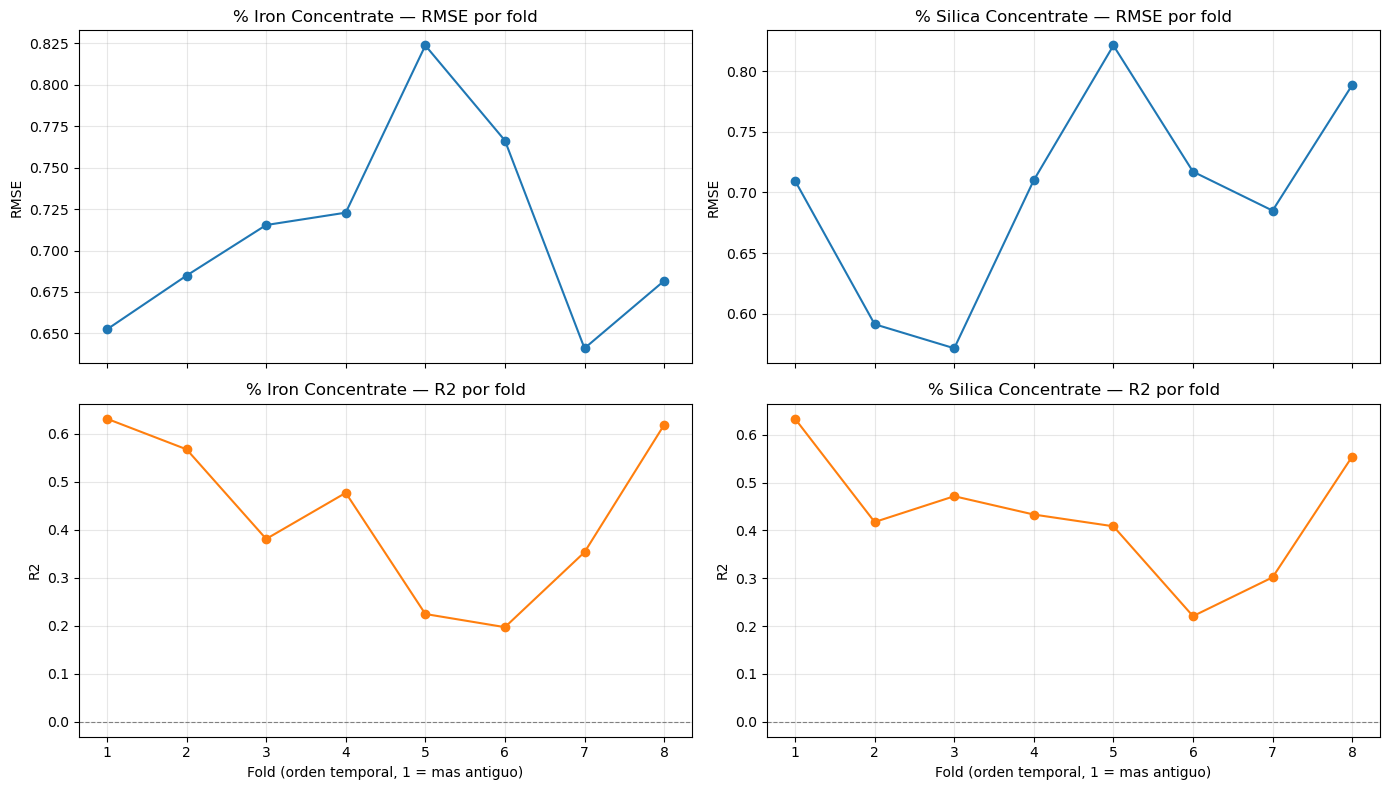

In [14]:
# --- Backtest de ventana deslizante (rolling-origin, walk-forward) ---
# El grid search de arriba solo da el RMSE PROMEDIADO entre los folds de
# walk-forward: si el modelo mejora o empeora segun avanza la campana, ese
# promedio lo esconde. Aqui reentrenamos con los mejores hiperparametros del
# grid search en cada fold por separado y guardamos el score de cada uno,
# para ver la tendencia fold a fold en vez de un unico numero agregado.
#
# Reusa los mismos folds 'tscv' (lista de (train_idx, val_idx)) definidos en
# la celda de grid search: ventana DESLIZANTE de tamano fijo (TRAIN_SIZE/
# VAL_SIZE), no expanding, así que la proporcion val/train es 80/20 en TODOS
# los folds, no solo en el ultimo.

best_params_flat = {k.replace('estimator__', ''): v for k, v in grid_search.best_params_.items()}

rolling_results = []
for fold_num, (train_idx, val_idx) in enumerate(tscv, start=1):
    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_model = MultiOutputRegressor(
        XGBRegressor(**best_params_flat, random_state=21, n_jobs=-1, tree_method='hist')
    )
    fold_model.fit(X_tr, y_tr)
    y_pred_val = pd.DataFrame(fold_model.predict(X_val), index=y_val.index, columns=TARGET)

    for col in TARGET:
        rolling_results.append({
            'fold': fold_num,
            'val_start': X_val.index.min(),
            'val_end': X_val.index.max(),
            'n_train': len(train_idx),
            'n_val': len(val_idx),
            'target': col,
            'RMSE': mean_squared_error(y_val[col], y_pred_val[col]) ** 0.5,
            'MAE': mean_absolute_error(y_val[col], y_pred_val[col]),
            'R2': r2_score(y_val[col], y_pred_val[col]),
        })

rolling_df = pd.DataFrame(rolling_results)
print(rolling_df.to_string(index=False))

# --- Grafica: RMSE y R2 por fold, un panel por target ---
# Si el modelo mejora al avanzar en el tiempo (mas historico disponible,
# o el proceso se vuelve mas predecible), el RMSE deberia bajar y el R2
# subir de izquierda a derecha. Una linea plana o que empeora sugiere que
# mas datos de entrenamiento no ayudan (o que el proceso cambia de regimen).
fig, axes = plt.subplots(2, len(TARGET), figsize=(7 * len(TARGET), 8), sharex=True)
for j, col in enumerate(TARGET):
    sub = rolling_df[rolling_df['target'] == col]
    axes[0, j].plot(sub['fold'], sub['RMSE'], marker='o')
    axes[0, j].set_title(f'{col} — RMSE por fold')
    axes[0, j].set_ylabel('RMSE')
    axes[0, j].grid(alpha=0.3)

    axes[1, j].plot(sub['fold'], sub['R2'], marker='o', color='tab:orange')
    axes[1, j].set_title(f'{col} — R2 por fold')
    axes[1, j].set_ylabel('R2')
    axes[1, j].set_xlabel('Fold (orden temporal, 1 = mas antiguo)')
    axes[1, j].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()


     % Iron Concentrate                                         \
        naive_constante naive_drift xgboost_test xgboost_train   
RMSE           0.823104    1.347382     0.800137      0.665369   
MAE            0.577030    0.967575     0.602011      0.487839   
R2             0.465612   -0.432067     0.494796      0.633055   

     % Silica Concentrate                                         
          naive_constante naive_drift xgboost_test xgboost_train  
RMSE             0.729469    1.149918     0.703990      0.647151  
MAE              0.447335    0.722855     0.488550      0.446764  
R2               0.604964    0.016879     0.631698      0.664596  


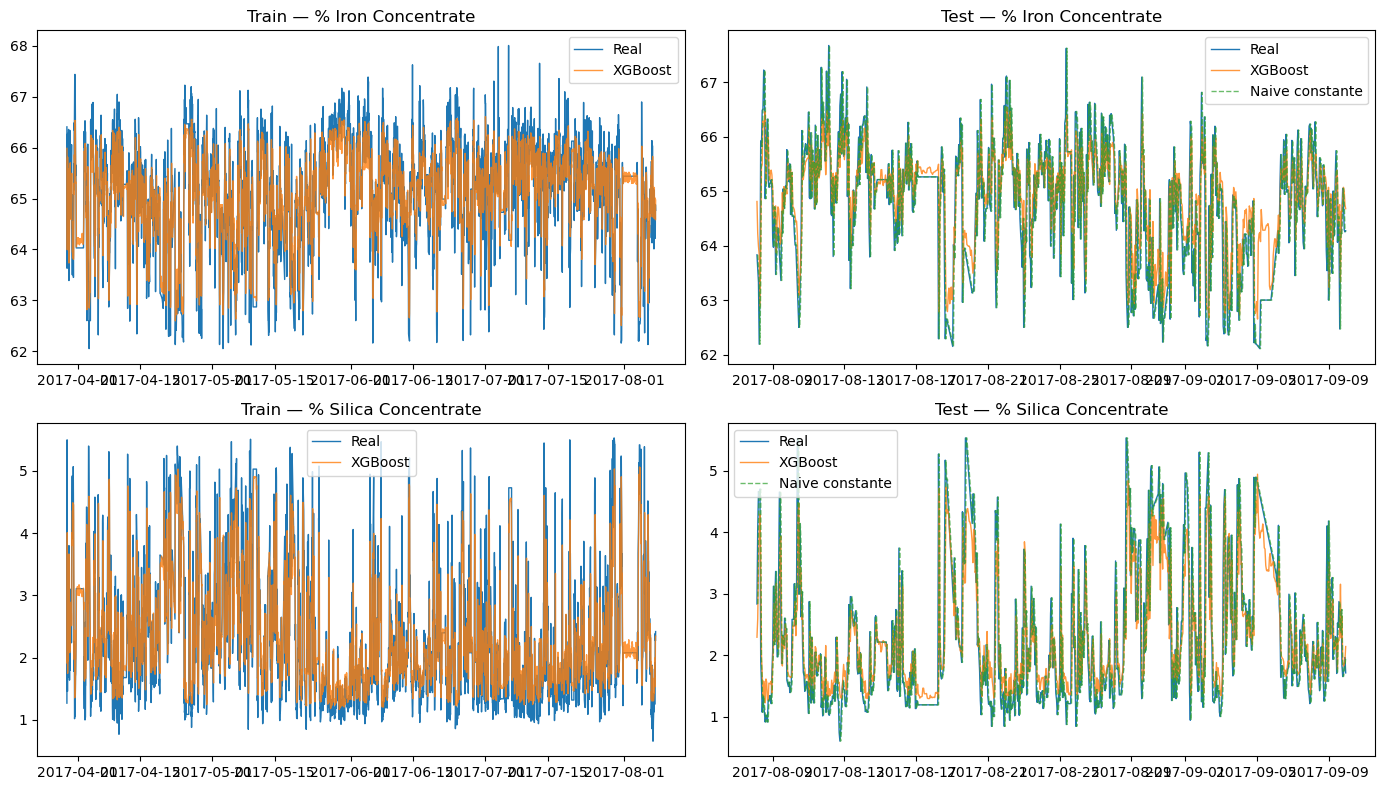

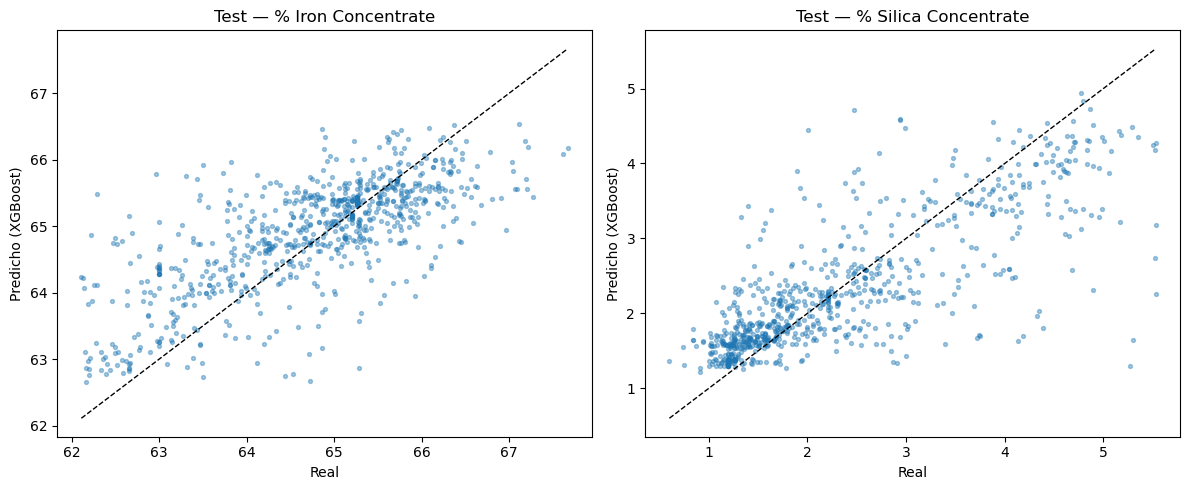

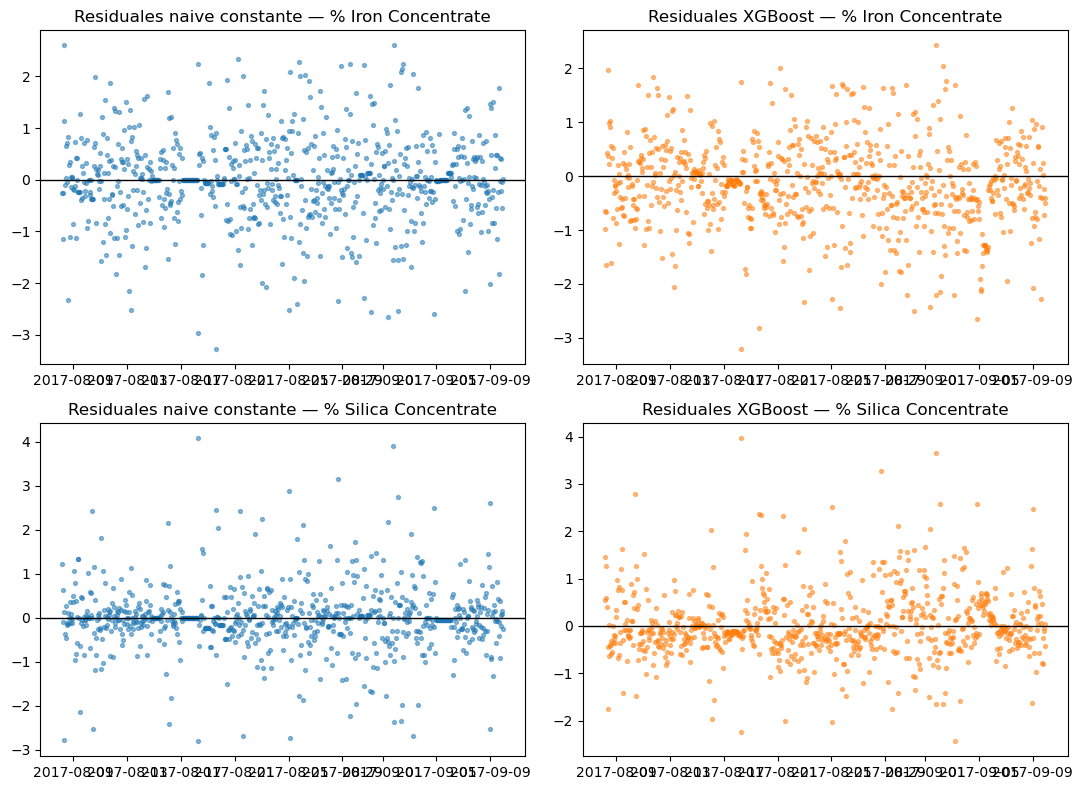

In [15]:
# --- Naive baselines realimentados (persistencia clasica de forecasting a 1 paso):
# usan el valor REAL del target en t (y t-1 para el drift) para predecir t+1, a
# diferencia de un naive "ciego" que no se realimenta. Se evalua sobre el tramo
# de test en resolucion horaria SIN desplazar (df[TARGET], no y_test que ya esta
# shiftado -HORIZON para el XGBoost).
target_series_test = df.loc[X_test.index.min():X_test.index.max(), TARGET]

# ============================================================
# NAIVE CONSTANTE (persistencia): pred(t+1) = target(t)
# ============================================================
def evaluate_naive_constant(df_eval, target_col):
    y_true = df_eval[target_col].iloc[1:].values          # valores reales en t+1
    y_pred = df_eval[target_col].iloc[:-1].values          # prediccion = valor en t
    return y_true, y_pred

# ============================================================
# NAIVE CON DRIFT: pred(t+1) = target(t) + [target(t) - target(t-1)]
# Requiere al menos 2 puntos de historia antes de poder predecir
# ============================================================
def evaluate_naive_drift(df_eval, target_col):
    y = df_eval[target_col].values
    y_true = y[2:]                          # valor real en t+1, empezando desde el 3er punto
    y_t     = y[1:-1]                       # valor en t
    y_t_1   = y[0:-2]                       # valor en t-1
    y_pred  = y_t + (y_t - y_t_1)           # persistencia + tendencia del paso anterior
    return y_true, y_pred

# --- Metricas: RMSE, MAE y R^2 (nunca solo R^2, como exige el criterio del proyecto) ---
naive_results = {}
for col in TARGET:
    yt_c, yp_c = evaluate_naive_constant(target_series_test, col)
    yt_d, yp_d = evaluate_naive_drift(target_series_test, col)

    naive_results[col] = {
        'naive_constante': {
            'RMSE': mean_squared_error(yt_c, yp_c) ** 0.5,
            'MAE': mean_absolute_error(yt_c, yp_c),
            'R2': r2_score(yt_c, yp_c),
        },
        'naive_drift': {
            'RMSE': mean_squared_error(yt_d, yp_d) ** 0.5,
            'MAE': mean_absolute_error(yt_d, yp_d),
            'R2': r2_score(yt_d, yp_d),
        },
        'xgboost_test': {
            'RMSE': mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test[col], y_pred_model[col]),
            'R2': r2_score(y_test[col], y_pred_model[col]),
        },
        'xgboost_train': {
            'RMSE': mean_squared_error(y_train[col], y_pred_train_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train[col], y_pred_train_model[col]),
            'R2': r2_score(y_train[col], y_pred_train_model[col]),
        },
    }

results = pd.DataFrame({(t, m): naive_results[t][m] for t in naive_results for m in naive_results[t]})
print(results)

# Predicciones naive realineadas al indice del target (para graficar junto al XGBoost)
y_pred_naive_const = pd.DataFrame(
    {col: evaluate_naive_constant(target_series_test, col)[1] for col in TARGET},
    index=target_series_test.index[1:],
)

# --- Graficas de prediccion: real vs. predicho, train y test, por target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    axes[i, 0].plot(y_train.index, y_train[col], label='Real', linewidth=1)
    axes[i, 0].plot(y_pred_train_model.index, y_pred_train_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 0].set_title(f'Train — {col}')
    axes[i, 0].legend()

    axes[i, 1].plot(y_test.index, y_test[col], label='Real', linewidth=1)
    axes[i, 1].plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 1].plot(y_pred_naive_const.index, y_pred_naive_const[col], label='Naive constante', linewidth=1, linestyle='--', alpha=0.7)
    axes[i, 1].set_title(f'Test — {col}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# --- Scatter real vs. predicho (test), por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(6 * len(TARGET), 5))
for i, col in enumerate(TARGET):
    ax = axes[i]
    ax.scatter(y_test[col], y_pred_model[col], s=8, alpha=0.4)
    lims = [min(y_test[col].min(), y_pred_model[col].min()), max(y_test[col].max(), y_pred_model[col].max())]
    ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho (XGBoost)')
    ax.set_title(f'Test — {col}')

plt.tight_layout()
plt.show()

# --- Residual plots: modelo vs. naive constante, para cada target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(11, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    resid_naive = target_series_test[col].iloc[1:].values - y_pred_naive_const[col].values
    resid_model = y_test[col] - y_pred_model[col]

    axes[i, 0].scatter(y_pred_naive_const.index, resid_naive, s=8, alpha=0.5)
    axes[i, 0].axhline(0, color='black', linewidth=1)
    axes[i, 0].set_title(f'Residuales naive constante — {col}')

    axes[i, 1].scatter(y_test.index, resid_model, s=8, alpha=0.5, color='tab:orange')
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'Residuales XGBoost — {col}')

plt.tight_layout()
plt.show()

In [20]:
# --- LSTM (Keras) multi-step: predice las proximas HORIZON=3 horas ---
# Arquitectura adaptada de una referencia externa: LSTM(elu, return_sequences)
# -> LSTM(softsign) -> Dropout(0.4) -> Dense(HORIZON * n_targets). La salida
# ya no es un unico paso (t) sino un vector con las HORIZON horas siguientes
# a la ventana, para cada target -- forecasting multi-step directo (un solo
# forward pass predice t+1..t+HORIZON, no se realimenta la prediccion).
#
# La ventana de entrada sigue usando el pasado real de las señales (WINDOW=12
# horas anteriores a t, igual que antes): cada muestra es (WINDOW, n_features)
# y su target es (HORIZON, n_targets) -- los valores reales en t, t+1, t+2.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

WINDOW = 12    # horas de contexto (pasado) que ve la LSTM en cada muestra
HORIZON = 3    # horas futuras a predecir de una vez (multi-step directo)

LSTM_FEATURE_COLS = [
    'Ore Pulp Density_mean',
    'Flotation Column 05 Air Flow_mean',
    'Amina Flow_mean',
    'Feed Iron_Silica_Mean',
    'Air Flow 1_2_3_Mean_mean',
    'Ore Pulp pH_mean',
]

# Feature autoregresivo: se añade el propio TARGET (Iron/Silica) como
# feature de entrada, ademas de los sensores de proceso. No es fuga de
# informacion porque la ventana de entrada es [t-WINDOW, t) -- SOLO horas
# ANTERIORES al primer paso predicho (t) -- y TARGET(t) en adelante nunca
# entra en esa ventana. En la practica equivale a "el ultimo valor de
# laboratorio conocido" en cada hora de la ventana (df[TARGET] es la ultima
# medida de laboratorio propagada por ffill), que es un dato real disponible
# para un operador en el momento de predecir.
LSTM_FEATURE_COLS_AUTOREG = LSTM_FEATURE_COLS + TARGET

lstm_raw = df[LSTM_FEATURE_COLS_AUTOREG].dropna()

# Mismo split temporal (80/20) que el resto del notebook, aplicado ANTES de
# construir las ventanas: asi ninguna ventana ni su horizonte de prediccion
# cruzan del tramo de train al de test.
lstm_split_idx = int(len(lstm_raw) * 0.8)
lstm_train_raw = lstm_raw.iloc[:lstm_split_idx]
lstm_test_raw = lstm_raw.iloc[lstm_split_idx:]

# Escalado z-score fit SOLO en train (igual que X_train_scaled/X_test_scaled
# del bloque XGBoost), para no filtrar estadisticos del test.
lstm_feat_mean = lstm_train_raw[LSTM_FEATURE_COLS_AUTOREG].mean()
lstm_feat_std = lstm_train_raw[LSTM_FEATURE_COLS_AUTOREG].std()

# El target tambien se normaliza (z-score, fit SOLO en train), ademas de las
# features. Sin esto, con loss='mae' en escala original (~60-68% Iron,
# ~1-6% Silica) el gradiente inicial mas facil de aprovechar es simplemente
# ajustar el sesgo de la capa Dense final hacia la media del target -- eso
# minimiza el MAE rapido al principio y, combinado con un EarlyStopping
# demasiado impaciente, deja al modelo "congelado" prediciendo casi una
# constante (la linea plana). Normalizar el target pone el gradiente en una
# escala donde aprender la dinamica real compite en igualdad con aprender la
# media.
lstm_target_mean = lstm_train_raw[TARGET].mean()
lstm_target_std = lstm_train_raw[TARGET].std()


def make_windows_multistep(raw_df, feat_mean, feat_std, target_mean, target_std,
                            window=WINDOW, horizon=HORIZON):
    """De un DataFrame horario (features + TARGET, este ultimo tambien como
    feature autoregresivo -- ver LSTM_FEATURE_COLS_AUTOREG) construye
    secuencias de entrada (window, n_features) y su target multi-step
    normalizado (horizon, n_targets): la ventana [t-window, t) predice los
    valores de TARGET en t, t+1, ..., t+horizon-1 (las horizon horas
    siguientes a la ventana, todas de una vez). La ventana de entrada solo
    contiene indices < t, asi que el TARGET dentro de la ventana es siempre
    pasado real, nunca el valor que se esta prediciendo."""
    feats_scaled = (raw_df[LSTM_FEATURE_COLS_AUTOREG] - feat_mean) / feat_std
    target_scaled = (raw_df[TARGET] - target_mean) / target_std
    X_seq, y_seq, idx_seq = [], [], []
    feat_values = feats_scaled.values
    target_values = target_scaled.values
    index = raw_df.index
    # el ultimo i valido es el que deja horizon pasos completos por delante
    for i in range(window, len(raw_df) - horizon + 1):
        X_seq.append(feat_values[i - window:i])
        y_seq.append(target_values[i:i + horizon])
        idx_seq.append(index[i])  # timestamp del primer paso predicho (t)
    return np.array(X_seq), np.array(y_seq), pd.DatetimeIndex(idx_seq)


train_X_lstm, train_y_lstm_scaled, train_idx_lstm = make_windows_multistep(
    lstm_train_raw, lstm_feat_mean, lstm_feat_std, lstm_target_mean, lstm_target_std)
test_X_lstm, test_y_lstm_scaled, test_idx_lstm = make_windows_multistep(
    lstm_test_raw, lstm_feat_mean, lstm_feat_std, lstm_target_mean, lstm_target_std)

# DataFrames/arrays propios de la LSTM en escala ORIGINAL (no la normalizada
# que se usa para entrenar). Forma (n_samples, HORIZON, n_targets) -- se usan
# en las celdas de metricas/graficas de mas abajo. NO se llaman y_train/
# y_test: tienen distinto numero de filas, indice Y FORMA que el split de
# XGBoost (aqui cada muestra tiene HORIZON pasos, no 1), asi que reusar los
# nombres globales pisaria y_train/y_test y romperia XGBoost si se reejecuta
# despues.
y_train_lstm = train_y_lstm_scaled * lstm_target_std.values + lstm_target_mean.values
y_test_lstm = test_y_lstm_scaled * lstm_target_std.values + lstm_target_mean.values

n_targets_lstm = len(TARGET)
n_features_lstm = len(LSTM_FEATURE_COLS_AUTOREG)

print(f'train_X_lstm: {train_X_lstm.shape}, train_y_lstm_scaled: {train_y_lstm_scaled.shape}')
print(f'test_X_lstm : {test_X_lstm.shape}, test_y_lstm_scaled : {test_y_lstm_scaled.shape}')
print(f'Ventana: {WINDOW}h de contexto -> predice TARGET en las {HORIZON} horas siguientes (multi-step directo)')


train_X_lstm: (3144, 12, 8), train_y_lstm_scaled: (3144, 3, 2)
test_X_lstm : (776, 12, 8), test_y_lstm_scaled : (776, 3, 2)
Ventana: 12h de contexto -> predice TARGET en las 3 horas siguientes (multi-step directo)


c:\Users\COMPUTAEX\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 3, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,454 (9.59 KB)

 Trainable params: 2,454 (9.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
99/99 - 3s - 31ms/step - loss: 0.7933 - val_loss: 0.8112
Epoch 2/500
99/99 - 1s - 5ms/step - loss: 0.7619 - val_loss: 0.7804
Epoch 3/500
99/99 - 0s - 5ms/step - loss: 0.7341 - val_loss: 0.7434
Epoch 4/500
99/99 - 0s - 5ms/step - loss: 0.7049 - val_loss: 0.7069
Epoch 5/500
99/99 - 0s - 5ms/step - loss: 0.6767 - val_loss: 0.6757
Epoch 6/500
99/99 - 1s - 6ms/step - loss: 0.6500 - val_loss: 0.6561
Epoch 7/500
99/99 - 1s - 6ms/step - loss: 0.6250 - val_loss: 0.6361
Epoch 8/500
99/99 - 1s - 5ms/step - loss: 0.6133 - val_loss: 0.6234
Epoch 9/500
99/99 - 0s - 5ms/step - loss: 0.5994 - val_loss: 0.6098
Epoch 10/500
99/99 - 1s - 9ms/step - loss: 0.5903 - val_loss: 0.6059
Epoch 11/500
99/99 - 0s - 5ms/step - loss: 0.5851 - val_loss: 0.6037
Epoch 12/500
99/99 - 1s - 5ms/step - loss: 0.5793 - val_loss: 0.5942
Epoch 13/500
99/99 - 0s - 5ms/step - loss: 0.5754 - val_loss: 0.5961
Epoch 14/500
99/99 - 1s - 5ms/step - loss: 0.5733 - val_loss: 0.5922
Epoch 15/500
99/99 - 0s - 5ms/step - loss:

In [21]:
# --- Grid search de arquitectura/regularizacion para la LSTM ---
# La curva de aprendizaje (training baja, validation sube desde ~epoca 10)
# mostraba overfitting. En vez de ajustar un hiperparametro a mano, se prueba
# una combinacion curada de ejes que mas afectan a capacidad/regularizacion:
# - units: tamaño de las capas LSTM (mas unidades = mas capacidad = mas
#   riesgo de overfitting con pocas features/muestras)
# - n_layers: 1 vs 2 capas LSTM apiladas
# - dropout: fraccion de unidades desactivadas antes de la capa Dense final
# - learning_rate: paso de Adam/AdamW
# - weight_decay: regularizacion L2 aplicada por el propio optimizador
#   (AdamW), penaliza pesos grandes independientemente del dropout
#
# NO es un grid cartesiano completo (séria 3*2*3*2*3 = 108 combinaciones,
# demasiado lento para iterar) -- es un conjunto curado de ~12 combinaciones
# que varian los ejes de forma dirigida: primero se compara capacidad
# (units/n_layers) con regularizacion fija, luego regularizacion (dropout/
# weight_decay) con capacidad fija en el valor mas prometedor.
#
# Cada combinacion se entrena con EarlyStopping mas corto (patience=15) que
# el entrenamiento final, solo para clasificar candidatos por su mejor
# val_loss -- no hace falta paciencia larga para EXPLORAR, solo para el
# entrenamiento definitivo del ganador.
import itertools
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping


def build_lstm(units, n_layers, dropout, learning_rate, weight_decay,
                input_shape, horizon, n_targets):
    layers = []
    for i in range(n_layers):
        is_last_lstm = (i == n_layers - 1)
        layers.append(LSTM(
            units=units,
            activation='elu' if i == 0 else 'softsign',
            return_sequences=not is_last_lstm,
            input_shape=input_shape if i == 0 else None,
        ))
    layers.append(Dropout(dropout))
    layers.append(Dense(horizon * n_targets))
    layers.append(Reshape((horizon, n_targets)))

    model = Sequential(layers)
    model.compile(
        loss='mae',
        optimizer=AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
    )
    return model


# Combinaciones curadas: (units, n_layers, dropout, learning_rate, weight_decay)
GRID = [
    # --- Baseline actual (para comparar contra el resto) ---
    (16, 2, 0.4, 1e-3, 0.0),
    # --- Variando capacidad (units/n_layers), regularizacion fija ---
    (8,  2, 0.4, 1e-3, 0.0),
    (32, 2, 0.4, 1e-3, 0.0),
    (16, 1, 0.4, 1e-3, 0.0),
    (32, 1, 0.4, 1e-3, 0.0),
    # --- Variando dropout, capacidad fija en 16/2 ---
    (16, 2, 0.2, 1e-3, 0.0),
    (16, 2, 0.5, 1e-3, 0.0),
    # --- Variando learning rate ---
    (16, 2, 0.4, 3e-4, 0.0),
    (16, 2, 0.4, 3e-3, 0.0),
    # --- Weight decay (regularizacion L2 via AdamW) con y sin dropout alto ---
    (16, 2, 0.2, 1e-3, 1e-4),
    (16, 2, 0.4, 1e-3, 1e-4),
    (8,  1, 0.3, 1e-3, 1e-4),
]

GRID_EPOCHS = 150
GRID_PATIENCE = 15

grid_results = []
input_shape = (train_X_lstm.shape[1], train_X_lstm.shape[2])

for units, n_layers, dropout, lr, wd in GRID:
    t0 = time.time()
    model = build_lstm(units, n_layers, dropout, lr, wd, input_shape, HORIZON, n_targets_lstm)
    hist = model.fit(
        train_X_lstm, train_y_lstm_scaled,
        epochs=GRID_EPOCHS,
        batch_size=32,
        validation_data=(test_X_lstm, test_y_lstm_scaled),
        verbose=0,
        shuffle=False,
        callbacks=[EarlyStopping(patience=GRID_PATIENCE, min_delta=1e-4, restore_best_weights=True)],
    )
    best_val = min(hist.history['val_loss'])
    best_train_at_best_val = hist.history['loss'][hist.history['val_loss'].index(best_val)]
    gap = best_val - best_train_at_best_val  # brecha train/val en el mejor punto -- proxy de overfitting
    n_epochs_run = len(hist.history['loss'])
    elapsed = time.time() - t0

    grid_results.append({
        'units': units, 'n_layers': n_layers, 'dropout': dropout,
        'lr': lr, 'weight_decay': wd,
        'best_val_loss': best_val, 'train_loss_at_best': best_train_at_best_val,
        'overfit_gap': gap, 'epochs_run': n_epochs_run, 'seconds': round(elapsed, 1),
    })
    print(f"units={units:2d} layers={n_layers} dropout={dropout:.1f} lr={lr:.0e} wd={wd:.0e} "
          f"-> best_val={best_val:.4f} gap={gap:+.4f} epochs={n_epochs_run} ({elapsed:.1f}s)")

grid_df = pd.DataFrame(grid_results).sort_values('best_val_loss')
print("\n=== Resultados ordenados por mejor val_loss (menor es mejor) ===")
print(grid_df.to_string(index=False))

best_config = grid_df.iloc[0]
print(f"\nMejor combinacion: units={best_config['units']:.0f}, n_layers={best_config['n_layers']:.0f}, "
      f"dropout={best_config['dropout']}, lr={best_config['lr']:.0e}, weight_decay={best_config['weight_decay']:.0e}")
print(f"(val_loss={best_config['best_val_loss']:.4f}, overfit_gap={best_config['overfit_gap']:+.4f})")


units=16 layers=2 dropout=0.4 lr=1e-03 wd=0e+00 -> best_val=0.5650 gap=+0.0203 epochs=33 (18.2s)
units= 8 layers=2 dropout=0.4 lr=1e-03 wd=0e+00 -> best_val=0.5654 gap=+0.0128 epochs=51 (24.9s)
units=32 layers=2 dropout=0.4 lr=1e-03 wd=0e+00 -> best_val=0.5649 gap=+0.0304 epochs=28 (18.4s)
units=16 layers=1 dropout=0.4 lr=1e-03 wd=0e+00 -> best_val=0.5387 gap=+0.0065 epochs=63 (21.3s)
units=32 layers=1 dropout=0.4 lr=1e-03 wd=0e+00 -> best_val=0.5369 gap=+0.0066 epochs=35 (14.4s)
units=16 layers=2 dropout=0.2 lr=1e-03 wd=0e+00 -> best_val=0.5693 gap=+0.0412 epochs=35 (23.7s)
units=16 layers=2 dropout=0.5 lr=1e-03 wd=0e+00 -> best_val=0.5813 gap=+0.0340 epochs=34 (25.5s)
units=16 layers=2 dropout=0.4 lr=3e-04 wd=0e+00 -> best_val=0.5644 gap=+0.0199 epochs=67 (55.4s)
units=16 layers=2 dropout=0.4 lr=3e-03 wd=0e+00 -> best_val=0.5642 gap=+0.0027 epochs=21 (19.1s)
units=16 layers=2 dropout=0.2 lr=1e-03 wd=1e-04 -> best_val=0.5476 gap=+0.0370 epochs=47 (38.9s)
units=16 layers=2 dropout=0.4 

In [22]:
# --- Entrenamiento final con la mejor combinacion del grid search ---
# Se reentrena desde cero (pesos nuevos) con la configuracion ganadora del
# grid, esta vez con la paciencia larga original (patience=50): el grid
# search exploraba con patience=15 (rapido, para clasificar candidatos), el
# entrenamiento final usa mas paciencia porque ya sabemos que esta
# combinacion es prometedora y merece la pena dejarla converger del todo.
# restore_best_weights=True asegura que el modelo final es el de mejor
# val_loss, no el de la ultima epoca (aunque seguiran corriendo epocas de
# ventana tras el mejor punto, por diseño de EarlyStopping con patience>0).
lstm_model = build_lstm(
    units=int(best_config['units']),
    n_layers=int(best_config['n_layers']),
    dropout=best_config['dropout'],
    learning_rate=best_config['lr'],
    weight_decay=best_config['weight_decay'],
    input_shape=input_shape,
    horizon=HORIZON,
    n_targets=n_targets_lstm,
)
lstm_model.summary()

history = lstm_model.fit(
    train_X_lstm,
    train_y_lstm_scaled,
    epochs=500,
    batch_size=32,
    validation_data=(test_X_lstm, test_y_lstm_scaled),
    verbose=2,
    shuffle=False,
    callbacks=[
        ModelCheckpoint('./LSTM_Flotation_ML.keras', save_best_only=True),
        EarlyStopping(patience=50, min_delta=1e-4, restore_best_weights=True),
    ])


c:\Users\COMPUTAEX\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 3, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598 (2.34 KB)

 Trainable params: 598 (2.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
99/99 - 2s - 20ms/step - loss: 0.8337 - val_loss: 0.7869
Epoch 2/500
99/99 - 0s - 4ms/step - loss: 0.7594 - val_loss: 0.7426
Epoch 3/500
99/99 - 0s - 4ms/step - loss: 0.7140 - val_loss: 0.7033
Epoch 4/500
99/99 - 0s - 4ms/step - loss: 0.6822 - val_loss: 0.6744
Epoch 5/500
99/99 - 0s - 5ms/step - loss: 0.6593 - val_loss: 0.6499
Epoch 6/500
99/99 - 0s - 4ms/step - loss: 0.6392 - val_loss: 0.6278
Epoch 7/500
99/99 - 0s - 5ms/step - loss: 0.6246 - val_loss: 0.6112
Epoch 8/500
99/99 - 0s - 4ms/step - loss: 0.6128 - val_loss: 0.6003
Epoch 9/500
99/99 - 0s - 5ms/step - loss: 0.6066 - val_loss: 0.5933
Epoch 10/500
99/99 - 0s - 5ms/step - loss: 0.6000 - val_loss: 0.5856
Epoch 11/500
99/99 - 0s - 4ms/step - loss: 0.5893 - val_loss: 0.5798
Epoch 12/500
99/99 - 0s - 4ms/step - loss: 0.5850 - val_loss: 0.5764
Epoch 13/500
99/99 - 0s - 4ms/step - loss: 0.5766 - val_loss: 0.5720
Epoch 14/500
99/99 - 0s - 4ms/step - loss: 0.5768 - val_loss: 0.5685
Epoch 15/500
99/99 - 0s - 4ms/step - loss:

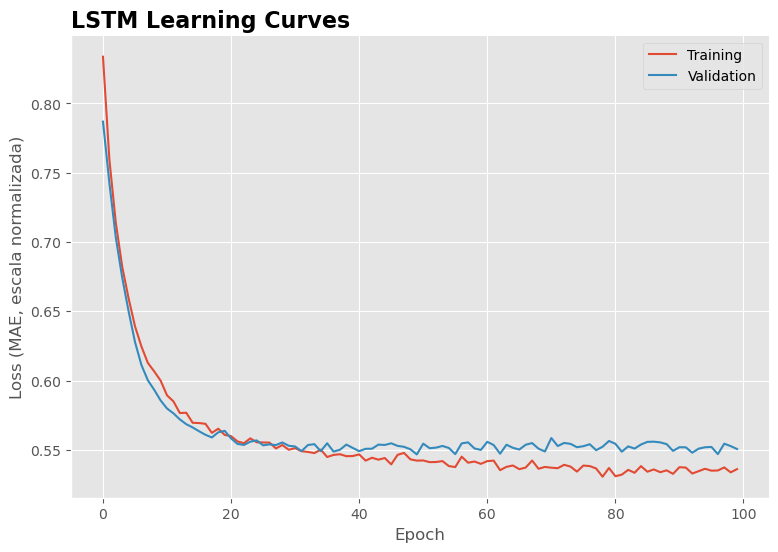

Best training loss   = 0.5306 at epoch 78
Best validation loss = 0.5467 at epoch 49


In [23]:
# --- Curvas de aprendizaje ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_loss, label='Training')
ax.plot(val_loss, label='Validation')
ax.set_title('LSTM Learning Curves', loc='left', weight='bold', size=16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MAE, escala normalizada)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

print(f'Best training loss   = {min(train_loss):.4f} at epoch {train_loss.index(min(train_loss))}')
print(f'Best validation loss = {min(val_loss):.4f} at epoch {val_loss.index(min(val_loss))}')

In [24]:
# --- Prediccion y metricas LSTM multi-step, por horizonte (h=1..HORIZON) ---
# El modelo se entreno con el target NORMALIZADO (z-score, ver celda
# anterior), asi que predict() devuelve valores en esa misma escala. Hay que
# deshacer la normalizacion (lstm_target_mean/std, fit en train) antes de
# comparar contra y_train_lstm/y_test_lstm (escala ORIGINAL).
#
# Con salida multi-step, y_*_lstm y las predicciones tienen forma
# (n_samples, HORIZON, n_targets): se reportan metricas separadas POR PASO
# de horizonte (h=1 es la hora siguiente a la ventana, h=HORIZON la mas
# lejana) -- es habitual que el error crezca con el horizonte, y agregar
# todo junto esconde esa degradacion.
y_pred_train_lstm_scaled = lstm_model.predict(train_X_lstm)
y_pred_test_lstm_scaled = lstm_model.predict(test_X_lstm)

y_pred_train_lstm = y_pred_train_lstm_scaled * lstm_target_std.values + lstm_target_mean.values
y_pred_test_lstm = y_pred_test_lstm_scaled * lstm_target_std.values + lstm_target_mean.values

lstm_results = {}
for col_i, col in enumerate(TARGET):
    lstm_results[col] = {}
    for h in range(HORIZON):
        y_true_train_h = y_train_lstm[:, h, col_i]
        y_pred_train_h = y_pred_train_lstm[:, h, col_i]
        y_true_test_h = y_test_lstm[:, h, col_i]
        y_pred_test_h = y_pred_test_lstm[:, h, col_i]

        lstm_results[col][f'lstm_train_h{h + 1}'] = {
            'RMSE': mean_squared_error(y_true_train_h, y_pred_train_h) ** 0.5,
            'MAE': mean_absolute_error(y_true_train_h, y_pred_train_h),
            'R2': r2_score(y_true_train_h, y_pred_train_h),
        }
        lstm_results[col][f'lstm_test_h{h + 1}'] = {
            'RMSE': mean_squared_error(y_true_test_h, y_pred_test_h) ** 0.5,
            'MAE': mean_absolute_error(y_true_test_h, y_pred_test_h),
            'R2': r2_score(y_true_test_h, y_pred_test_h),
        }

# lstm_results['lstm_test'] / ['lstm_train'] = alias al horizonte h=1, para
# que la celda de comparativa final (que compara contra XGBoost/naive a 1
# paso) siga funcionando sin cambios.
for col in TARGET:
    lstm_results[col]['lstm_train'] = lstm_results[col]['lstm_train_h1']
    lstm_results[col]['lstm_test'] = lstm_results[col]['lstm_test_h1']

lstm_results_df = pd.DataFrame({(t, m): lstm_results[t][m] for t in lstm_results for m in lstm_results[t]})
print(lstm_results_df)


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
     % Iron Concentrate                                                        \
          lstm_train_h1 lstm_test_h1 lstm_train_h2 lstm_test_h2 lstm_train_h3   
RMSE           0.702949     0.750885      0.806190     0.844800      0.879319   
MAE            0.511007     0.565372      0.594581     0.638921      0.657831   
R2             0.590806     0.547015      0.461665     0.426747      0.359090   

                                       % Silica Concentrate               \
     lstm_test_h3 lstm_train lstm_test        lstm_train_h1 lstm_test_h1   
RMSE     0.933049   0.702949  0.750885             0.695320     0.704902   
MAE      0.703492   0.511007  0.565372             0.462392     0.490748   
R2       0.300222   0.590806  0.547015             0.612912     0.627687   

                                                                       \
     lstm_train_h2 lstm_test_h2 lstm_train_h3 lstm_test_h3 ls

                                          RMSE       MAE        R2
target               method                                       
% Iron Concentrate   naive_constante  0.823104  0.577030  0.465612
                     naive_drift      1.347382  0.967575 -0.432067
                     xgboost_test     0.800137  0.602011  0.494796
                     lstm_test        0.750885  0.565372  0.547015
% Silica Concentrate naive_constante  0.729469  0.447335  0.604964
                     naive_drift      1.149918  0.722855  0.016879
                     xgboost_test     0.703990  0.488550  0.631698
                     lstm_test        0.704902  0.490748  0.627687


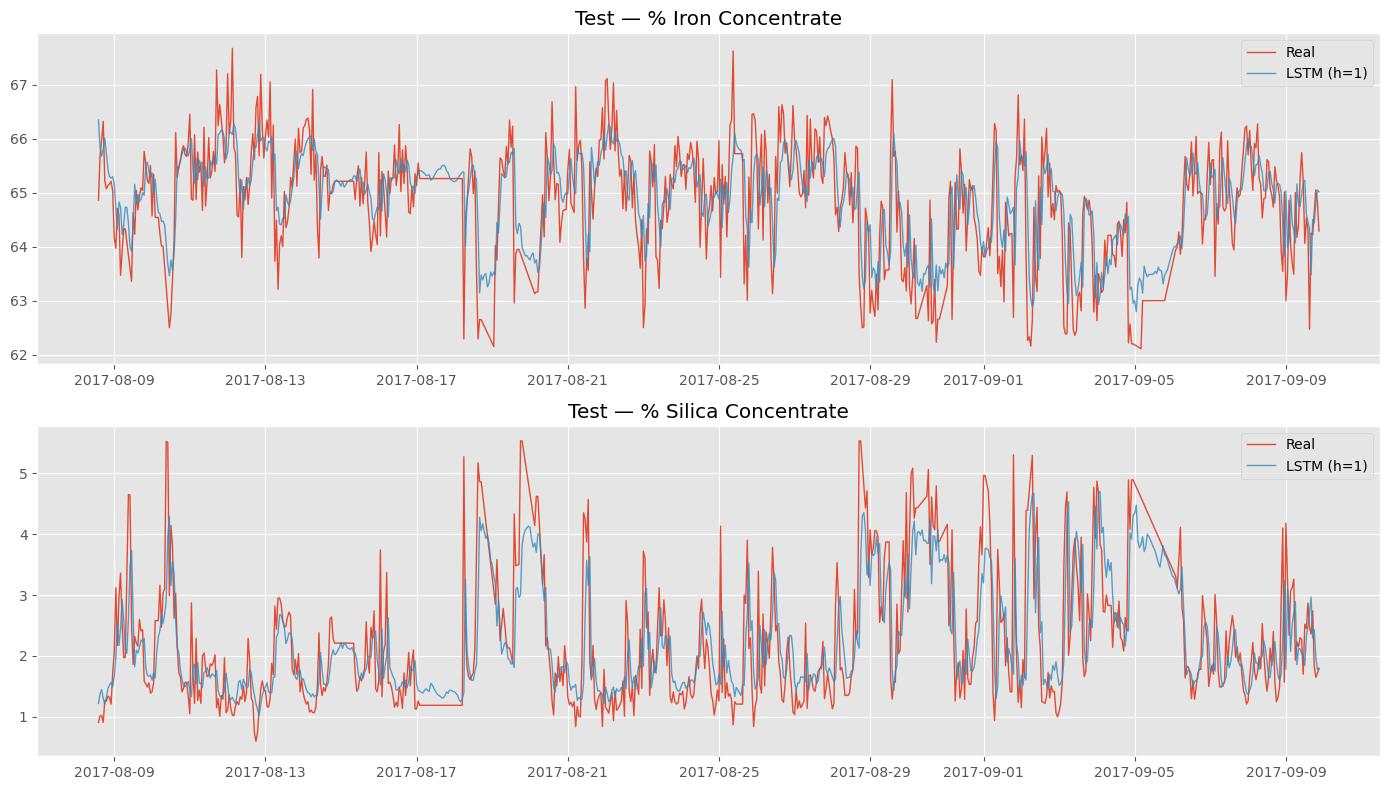

: 

In [ ]:
# --- Comparativa final: LSTM vs. XGBoost vs. naive baselines (test), por target ---
# La comparativa usa el horizonte h=1 de la LSTM (lstm_results[col]['lstm_test'],
# alias de 'lstm_test_h1' -- ver celda anterior) para que sea comparable con
# XGBoost/naive, que solo predicen 1 paso adelante. El desglose completo por
# horizonte (h=1..HORIZON) esta en lstm_results_df de la celda anterior.
comparison_rows = []
for col in TARGET:
    for method, metrics in [
        ('naive_constante', naive_results[col]['naive_constante']),
        ('naive_drift', naive_results[col]['naive_drift']),
        ('xgboost_test', naive_results[col]['xgboost_test']),
        ('lstm_test', lstm_results[col]['lstm_test']),
    ]:
        comparison_rows.append({'target': col, 'method': method, **metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index(['target', 'method'])
print(comparison_df)

# --- Graficas: real vs. predicho (test, horizonte h=1), LSTM vs. XGBoost ---
# y_test_lstm tiene forma (n_samples, HORIZON, n_targets); se grafica el
# paso h=1 (la prediccion a 1 hora, la mas comparable con XGBoost) usando
# test_idx_lstm como eje temporal (timestamp del primer paso predicho).
fig, axes = plt.subplots(len(TARGET), 1, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    ax = axes[i] if len(TARGET) > 1 else axes
    ax.plot(test_idx_lstm, y_test_lstm[:, 0, i], label='Real', linewidth=1)
    # ax.plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    ax.plot(test_idx_lstm, y_pred_test_lstm[:, 0, i], label='LSTM (h=1)', linewidth=1, alpha=0.8)
    ax.set_title(f'Test — {col}')
    ax.legend()

plt.tight_layout()
plt.show()
